# Metabolic "Orphan" Predicting Immune Evasion

**Research Question 1:** Can metabolic "orphan" interactions predict immune evasion across tumor types?

This notebook systematically cross-references our computationally predicted, literature-sparse ("Tier 2/3") metabolic target pairs against immune cell populations (such as B-cells, macrophages, and dendritic cells) in our cancer datasets. 

By identifying uncharacterized metabolic ligands that are heavily upregulated in these immune populations, we can potentially discover novel, unpatented immune-checkpoints driven by the metabolic microenvironment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import sys

# Define workspace
workspace_dir = '../'
output_dir = os.path.join(workspace_dir, 'output')
sys.path.append(output_dir)

# We use the parse_md_tables script to extract previously computed DE tables from HTML reports
from parse_md_tables import TableExtractor

print("Loading comprehensive target pairs...")
pairs_df = pd.read_csv(os.path.join(output_dir, 'human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv'))

# Explode Target column just in case it has commas
pairs_df['Target'] = pairs_df['Target'].astype(str).str.split(r'[,;]')
pairs_df = pairs_df.explode('Target')
pairs_df['Target'] = pairs_df['Target'].str.strip()

print(f"Total unique pairs loaded: {len(pairs_df)}")


Done parsing tables to /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/parsed_md_tables.txt.
Loading comprehensive target pairs...
Total unique pairs loaded: 13077


/var/folders/r4/pjgb1k_x7fv9xgcb_dg70bnm0000gn/T/ipykernel_41163/2241264976.py:18: DtypeWarning: Columns (37,39,40,45,46,47,54,56,61,100) have mixed types. Specify dtype option on import or set low_memory=False.
  pairs_df = pd.read_csv(os.path.join(output_dir, 'human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv'))


## 1. Isolate the "Orphan" (Tier 2 & 3 Pairs)

We define "Orphan" pairs as those that are supported by 2-3 databases but lack heavy, redundant validation (which would make them Tier 1).

In [2]:
def calc_tier(db_str):
    if pd.isna(db_str): return 'Tier 3 (Low)'
    count = len(str(db_str).split(','))
    if count >= 4: return 'Tier 1 (High)'
    elif count >= 2: return 'Tier 2 (Medium)'
    else: return 'Tier 3 (Low)'

pairs_df['Pair_Confidence_Tier'] = pairs_df['database'].apply(calc_tier)

orphan_metabolic_pairs = pairs_df[pairs_df['Pair_Confidence_Tier'].isin(['Tier 2 (Medium)', 'Tier 3 (Low)'])]
print(f"Orphan pairs identified: {len(orphan_metabolic_pairs)}")


Orphan pairs identified: 12806


## 2. Extract Highly Enriched Immune Targets

We parse the existing `cancer_*.html` reports to extract the genome-wide Differential Expression (DE) tables. We specifically filter for targets highly upregulated (`Log2FC > 1.0`, `padj < 0.05`) in immune clusters like B cells, Macrophages, and Dendritic cells.

In [3]:
html_files = glob.glob(os.path.join(output_dir, 'cancer_*.html'))
immune_enriched_genes = []

print("Parsing DE tables from HTMLs...")
for f in html_files:
    cancer_name = os.path.basename(f).replace('cancer_', '').split('_')[0]
    try:
        with open(f, 'r', encoding='utf-8') as inf:
            content = inf.read()
        extractor = TableExtractor()
        extractor.feed(content)
        
        # Search for DE Table
        de_table = None
        for tbl in extractor.tables:
            if not tbl: continue
            header = tbl[0]
            if 'logfoldchanges' in header and 'names' in header and 'group' in header:
                de_table = pd.DataFrame(tbl[1:], columns=header)
                break
        
        if de_table is not None:
            de_table['logfoldchanges'] = pd.to_numeric(de_table['logfoldchanges'], errors='coerce')
            de_table['pvals_adj'] = pd.to_numeric(de_table['pvals_adj'], errors='coerce')
            
            # Filter for immune cells
            immune_mask = de_table['group'].str.contains('B cell|Macrophage|mononuclear phagocyte|dendritic cell|T cell', case=False, na=False)
            sig_mask = (de_table['logfoldchanges'] > 1.0) & (de_table['pvals_adj'] < 0.05)
            filtered = de_table[immune_mask & sig_mask].copy()
            filtered['Cancer'] = cancer_name
            
            immune_enriched_genes.append(filtered)
            
    except Exception as e:
        print(f"Error parsing {f}: {e}")

immune_de_df = pd.concat(immune_enriched_genes, ignore_index=True)
print(f"Found {len(immune_de_df['names'].unique())} unique highly enriched immune target genes across all cancers.")


Parsing DE tables from HTMLs...
Found 32 unique highly enriched immune target genes across all cancers.


## 3. Map Orphan Metabolites to Immune Targets

We cross-reference our immune DE genes with the Orphan pairs, and visualize the top hits.

Identified 890 critical immune evasion orphan interactions.


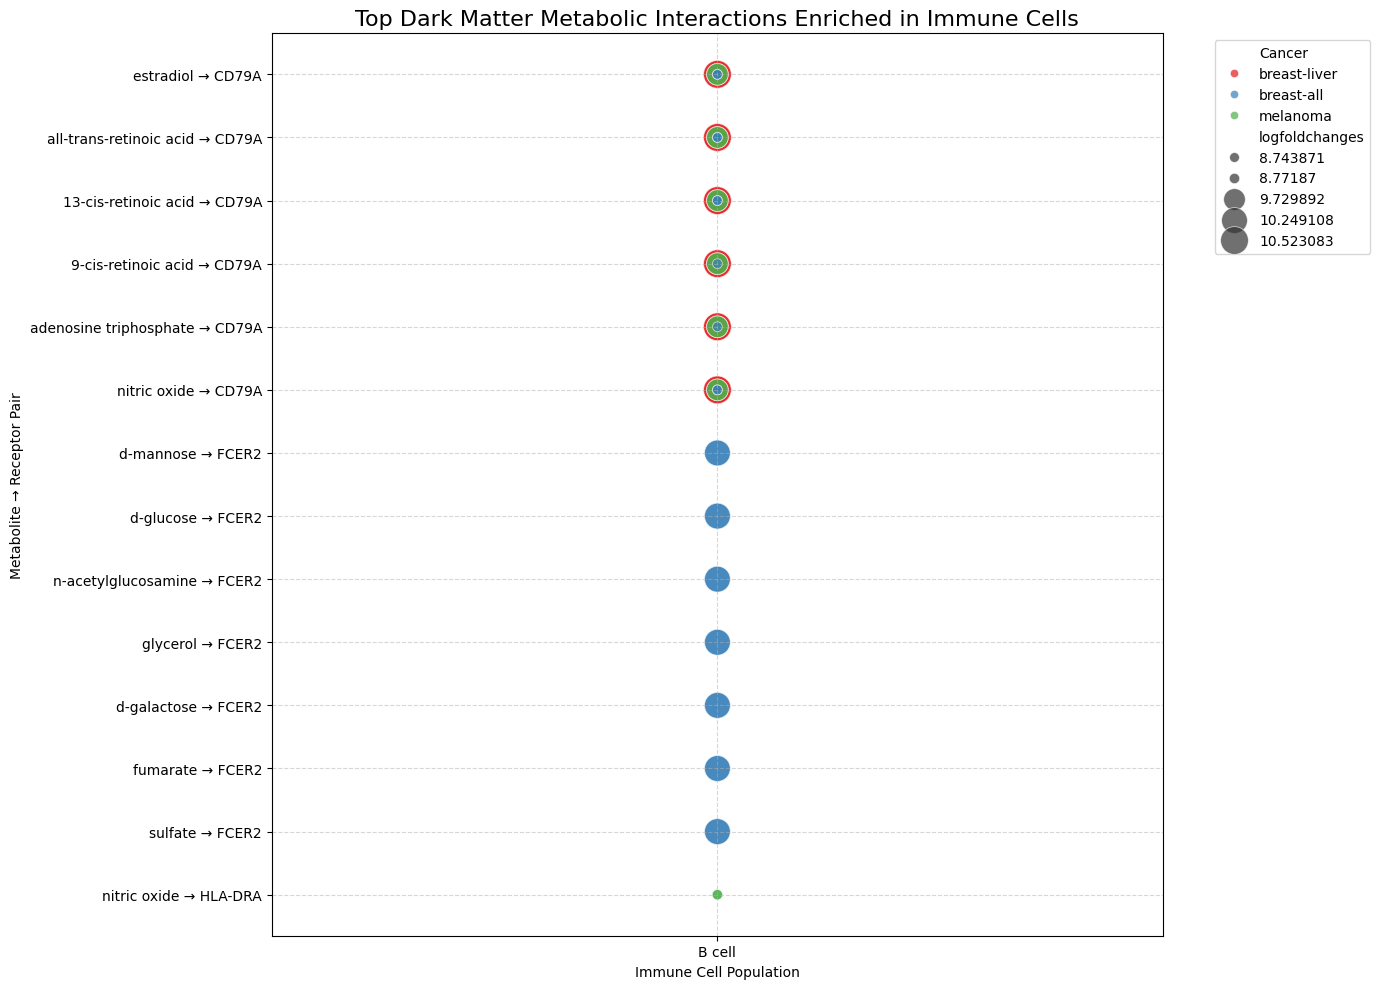

In [4]:
# Inner merge to find the intersection
orphan_metabolic_immune_df = pd.merge(
    immune_de_df, 
    orphan_metabolic_pairs, 
    left_on='names', 
    right_on='Target', 
    how='inner'
)

print(f"Identified {len(orphan_metabolic_immune_df)} critical immune evasion orphan interactions.")

# Sort by Log2FC
top_hits = orphan_metabolic_immune_df.sort_values(by='logfoldchanges', ascending=False).head(50)

# Create a clean label for plotting
top_hits['Interaction'] = top_hits['Metabolite_Name'] + ' → ' + top_hits['Target']

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=top_hits,
    y='Interaction',
    x='Cell_Type' if 'Cell_Type' in top_hits.columns else 'group',
    hue='Cancer',
    size='logfoldchanges',
    sizes=(50, 400),
    alpha=0.7,
    palette='Set1'
)
plt.title("Top Orphan Metabolic Interactions Enriched in Immune Cells", fontsize=16)
plt.xlabel("Immune Cell Population")
plt.ylabel("Metabolite → Receptor Pair")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [5]:
# Save the comprehensive list for manual review
output_csv = os.path.join(output_dir, 'immune_evasion_orphan_metabolic_candidates.csv')
orphan_metabolic_immune_df.to_csv(output_csv, index=False)
print(f"Saved highly confident orphan candidates to {output_csv}")

# Display top 10
orphan_metabolic_immune_df[['Cancer', 'group', 'names', 'logfoldchanges', 'Metabolite_Name', 'Pair_Confidence_Tier']].sort_values(by='logfoldchanges', ascending=False).head(10)


Saved highly confident orphan candidates to ../output/immune_evasion_orphan_metabolic_candidates.csv


,Cancer,group,names,logfoldchanges,Metabolite_Name,Pair_Confidence_Tier
10,breast-liver,B cell,CD79A,10.523083,estradiol,Tier 3 (Low)
15,breast-liver,B cell,CD79A,10.523083,all-trans-retinoic acid,Tier 3 (Low)
4,breast-liver,B cell,CD79A,10.523083,13-cis-retinoic acid,Tier 3 (Low)
5,breast-liver,B cell,CD79A,10.523083,13-cis-retinoic acid,Tier 3 (Low)
6,breast-liver,B cell,CD79A,10.523083,9-cis-retinoic acid,Tier 3 (Low)
7,breast-liver,B cell,CD79A,10.523083,9-cis-retinoic acid,Tier 3 (Low)
8,breast-liver,B cell,CD79A,10.523083,adenosine triphosphate,Tier 3 (Low)
9,breast-liver,B cell,CD79A,10.523083,adenosine triphosphate,Tier 3 (Low)
11,breast-liver,B cell,CD79A,10.523083,estradiol,Tier 3 (Low)
12,breast-liver,B cell,CD79A,10.523083,nitric oxide,Tier 3 (Low)
